In [1]:
#Import Libs
from matplotlib import pyplot as plot
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import random
import math
import cv2

In [2]:
#Function to Load a Image from Github
def display_image_from_url(image_url):
    with urllib.request.urlopen(image_url) as url:
        s = url.read()
    img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [3]:
#Import Image
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/lenna.jpg'
img = display_image_from_url(image_url)

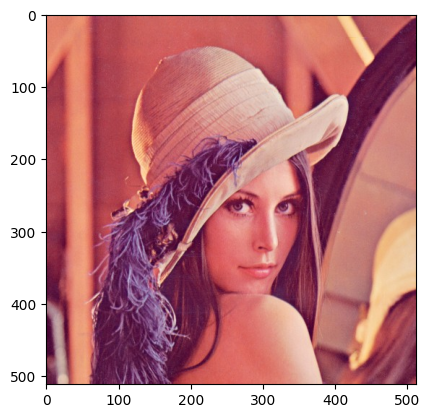

In [4]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

### **Image Histogram**

An **image histogram** is a graphical representation of the tonal distribution in a digital image. It plots the number of pixels for each tonal value. In a grayscale image, for example, the horizontal axis (X-axis) typically represents the intensity values (from 0 for pure black to 255 for pure white), and the vertical axis (Y-axis) represents the number of pixels at that intensity.

For a color image, you can have a histogram for each color channel (e.g., Red, Green, Blue). The histogram essentially gives you a statistical summary of the image's pixel values.

In cases evolving images, its possible use the **`ravel()`** function. Its a powerful tool in NumPy for flattening multi-dimensional arrays into a one-dimensional array. It returns a **contiguous flattened array**. What it does:

*   If you have an array with multiple dimensions (e.g., a 2D image represented as `(height, width)` or a 3D color image `(height, width, channels)`), `ravel()` will convert it into a single, long sequence of elements.
*   The order of elements in the flattened array follows a C-style (row-major) order by default, meaning elements from the first row are listed, then elements from the second row, and so on.


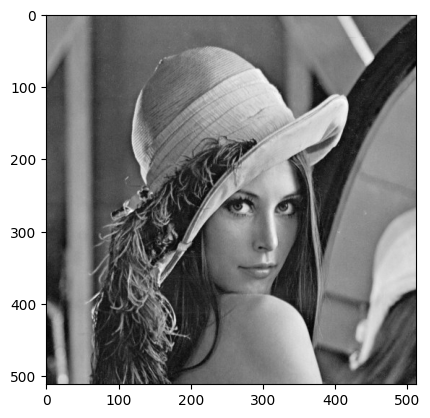

In [5]:
#Convert the Image From RGB to GrayScale
img_gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plot.imshow(img_gray,cmap='gray')
plot.show()

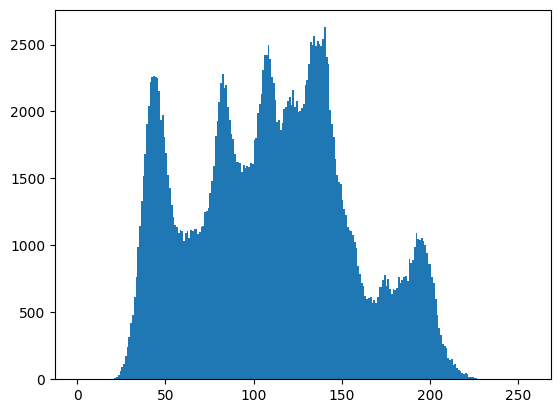

In [6]:
#Calc the Histogram of the Image
histogram = plot.hist(img_gray.ravel(), bins=256, range=[0,256]);
np.set_printoptions(suppress=True);

In [7]:
#Calc the Relative Histogram
num_lin = img_gray.shape[0]
num_col = img_gray.shape[1]
total = num_lin * num_col
histogram = histogram[0]
hr = histogram / total

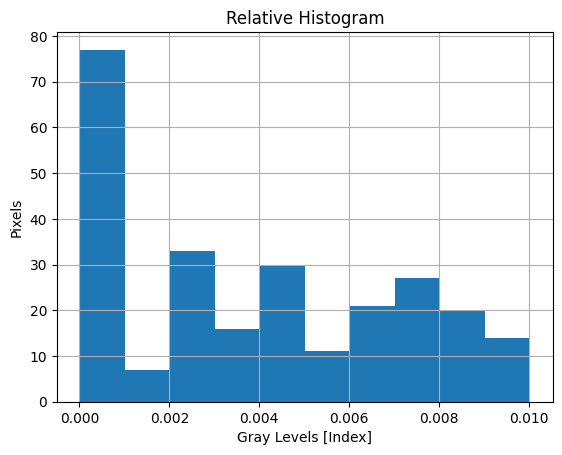

In [8]:
#Show the Relative Histogram
plot.hist(hr.ravel())
plot.xlabel('Gray Levels [Index]')
plot.ylabel('Pixels')
plot.title('Relative Histogram')
plot.grid(True)
plot.show()

In [9]:
#Histogram Equalization
img_eq = cv2.equalizeHist(img_gray)

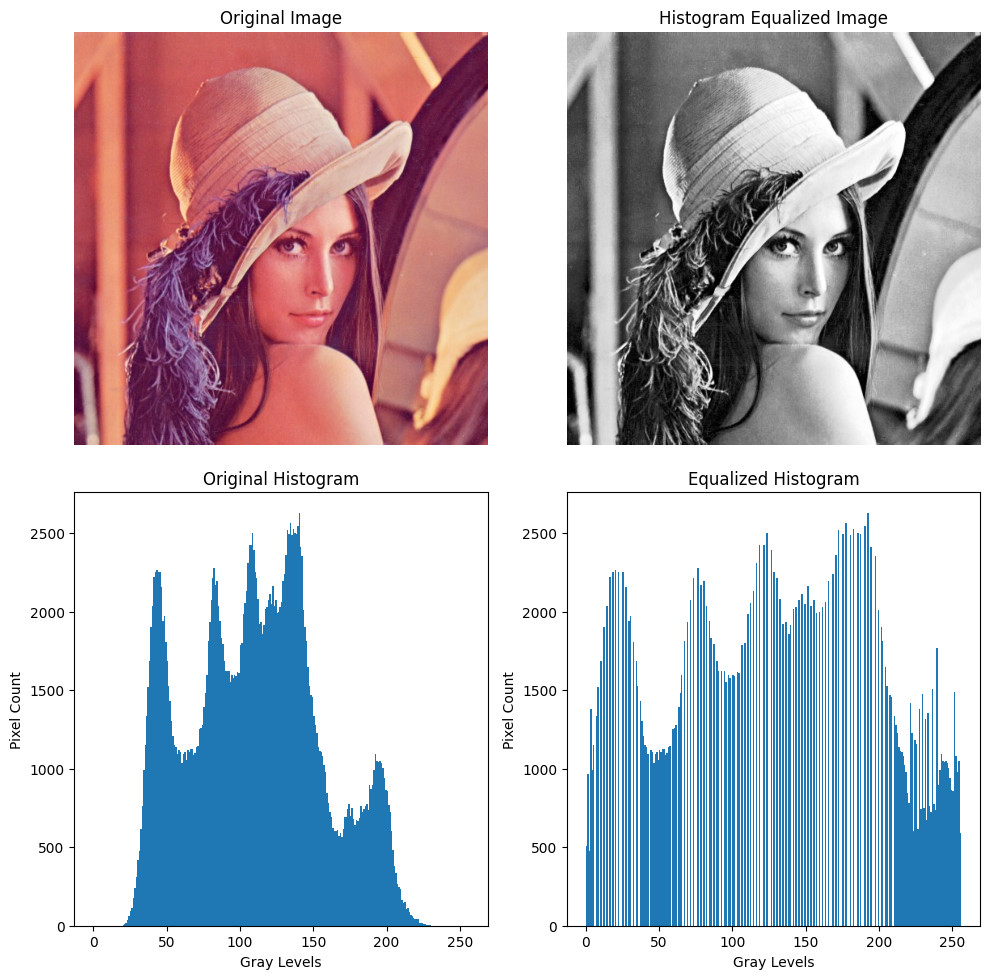

In [10]:
#Show the Results
fig, axs = plot.subplots(2, 2, figsize=(10, 10))

# Display Original Image
axs[0, 0].imshow(img)
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')

# Display Histogram Equalized Image
axs[0, 1].imshow(img_eq, cmap='gray')
axs[0, 1].set_title('Histogram Equalized Image')
axs[0, 1].axis('off')

# Display Original Histogram
axs[1, 0].hist(img_gray.ravel(), bins=256, range=[0,256])
axs[1, 0].set_title('Original Histogram')
axs[1, 0].set_xlabel('Gray Levels')
axs[1, 0].set_ylabel('Pixel Count')

# Display Equalized Histogram
axs[1, 1].hist(img_eq.ravel(), bins=256, range=[0,256])
axs[1, 1].set_title('Equalized Histogram')
axs[1, 1].set_xlabel('Gray Levels')
axs[1, 1].set_ylabel('Pixel Count')

plot.tight_layout()
plot.show()